# Exploratory Data Analysis and Feature Selection


### Setup

Feature selection uses 2022-2024 only. The 2025 validation data and 2026 test data are kept separate.


In [ ]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

CONFIG = json.loads(
    (ROOT / "config/project_config.json").read_text(encoding="utf-8")
)
LABELS = CONFIG["bin_labels"]
PRIMARY_HORIZON = int(CONFIG["primary_horizon"])
START_DATE = pd.Timestamp(CONFIG["start_date"])
VALIDATION_START_DATE = pd.Timestamp(CONFIG["validation_start_date"])
TEST_START_DATE = pd.Timestamp(CONFIG["test_start_date"])
END_DATE_EXCLUSIVE = pd.Timestamp(CONFIG["end_date_exclusive"])

modeling_data = pd.read_parquet(
    ROOT / f"data/modeling/sfo_delay_features_{PRIMARY_HORIZON}h.parquet"
)
operated = modeling_data.loc[modeling_data["target_delay_bin"].notna()]
training_df = operated.loc[operated["flight_date"] < VALIDATION_START_DATE]

# A fixed sample keeps the dense plots readable.
plot_sample_df = training_df.sample(
    min(len(training_df), 15_000),
    random_state=CONFIG["seed"],
)


### Modeling data by period

The delay analysis includes operated flights with a known departure delay. Cancelled flights remain in the parquet file but are not assigned a delay bin.


In [2]:
periods = pd.cut(
    operated["flight_date"],
    bins=[START_DATE, VALIDATION_START_DATE, TEST_START_DATE, END_DATE_EXCLUSIVE],
    labels=[
        f"train: {START_DATE.date()} to {(VALIDATION_START_DATE - pd.Timedelta(days=1)).date()}",
        f"validation: {VALIDATION_START_DATE.date()} to {(TEST_START_DATE - pd.Timedelta(days=1)).date()}",
        f"test: {TEST_START_DATE.date()} to {(END_DATE_EXCLUSIVE - pd.Timedelta(days=1)).date()}",
    ],
    right=False,
)

display(periods.value_counts(sort=False).rename("operated_flights").to_frame())


,operated_flights
flight_date,
train: 2022-2024,293770
validation: 2025,109971
test: Jan-May 2026,45646


### How common is each delay bin?


,flights,percent
target_delay_bin_label,,
under_15,231634,78.85
15_to_under_60,41573,14.15
60_to_under_120,12927,4.4
120_to_under_240,5752,1.96
240_plus,1884,0.64


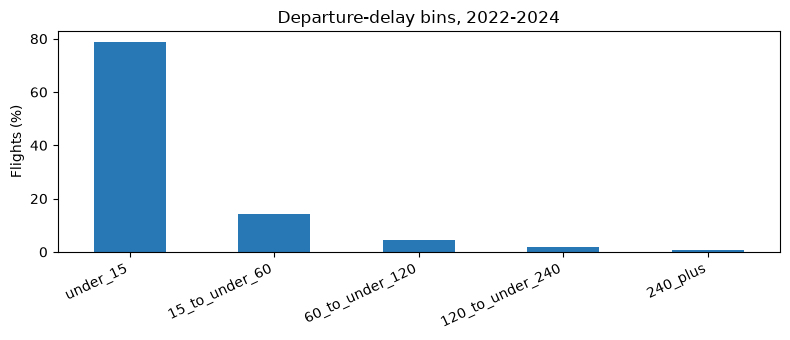

In [3]:
target_counts = training_df["target_delay_bin_label"].value_counts().reindex(LABELS)
target_distribution = pd.DataFrame(
    {
        "flights": target_counts,
        "percent": 100 * target_counts / target_counts.sum(),
    }
)
display(target_distribution.round(2))

ax = target_distribution["percent"].plot.bar(
    figsize=(8, 3.5), color="#2878B5", ylabel="Flights (%)"
)
ax.set_xlabel("")
ax.set_title("Departure-delay bins, 2022-2024")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Distribution of departure delay

Departure delay has a long right tail. The plot stops at four hours for readability, but the underlying data are not capped.


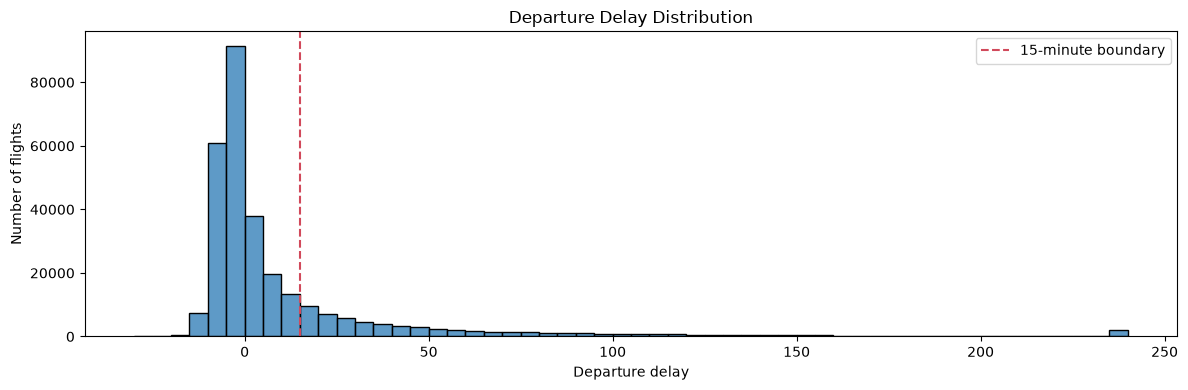

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.histplot(
    training_df["dep_delay_minutes"].clip(-30, 240),
    bins=54,
    color="#2878B5",
    ax=ax,
)

ax.axvline(
    15,
    color="#D1495B",
    linestyle="--",
    label="15-minute boundary",
)

ax.set_title("Departure Delay Distribution")
ax.set_xlabel("Departure delay")
ax.set_ylabel("Number of flights")
ax.legend()

plt.tight_layout()
plt.show()

### Do airlines have different delay rates?

Airlines follow different schedules and route networks, so carrier may help explain delay risk.


,flights,delay_ge_15_percent,delay_ge_60_percent,delay_ge_120_percent,median_delay_minutes
reporting_airline,,,,,
F9,10051,35.53,14.91,5.78,1.0
WN,24185,30.58,7.94,2.11,3.0
UA,141265,20.22,6.7,2.43,-1.0
AS,36009,20.21,5.97,1.96,-3.0
B6,14453,19.54,8.16,3.47,-4.0
AA,29381,19.36,7.33,3.42,-3.0
DL,36214,18.0,5.83,2.38,-1.0
HA,2212,13.47,4.02,1.81,-1.0


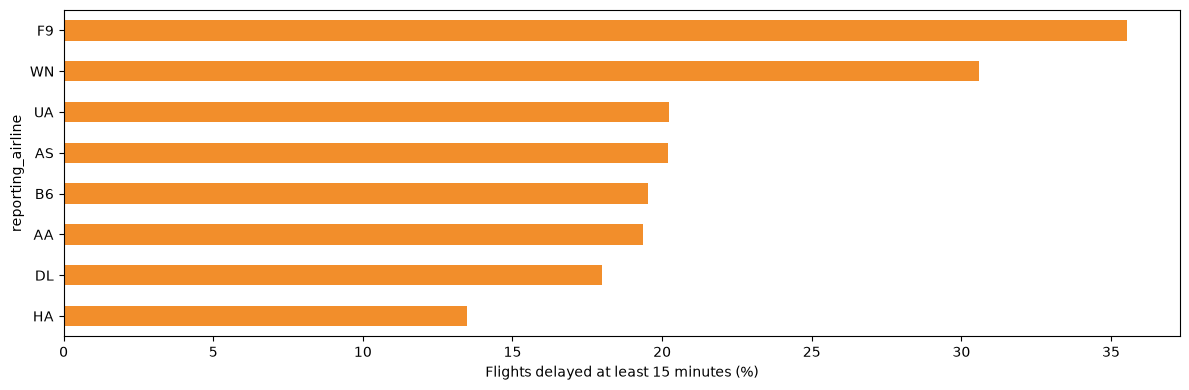

In [5]:
airline_summary = (
    training_df.groupby("reporting_airline", observed=True)
    .agg(
        flights=("flight_id", "size"),
        delay_ge_15_percent=("target_delay_ge_15", lambda x: 100 * x.mean()),
        delay_ge_60_percent=("target_delay_bin", lambda x: 100 * x.ge(2).mean()),
        delay_ge_120_percent=("target_delay_bin", lambda x: 100 * x.ge(3).mean()),
        median_delay_minutes=("dep_delay_minutes", "median"),
    )
    .sort_values("delay_ge_15_percent", ascending=False)
)
display(airline_summary.round(2))

airline_summary["delay_ge_15_percent"].sort_values().plot.barh(
    figsize=(12, 4), color="#F28E2B",
    xlabel="Flights delayed at least 15 minutes (%)",
)
plt.tight_layout()
plt.show()


### Does scheduled time matter?

This compares the percentage of flights delayed at least 15 minutes by weekday and scheduled departure hour.


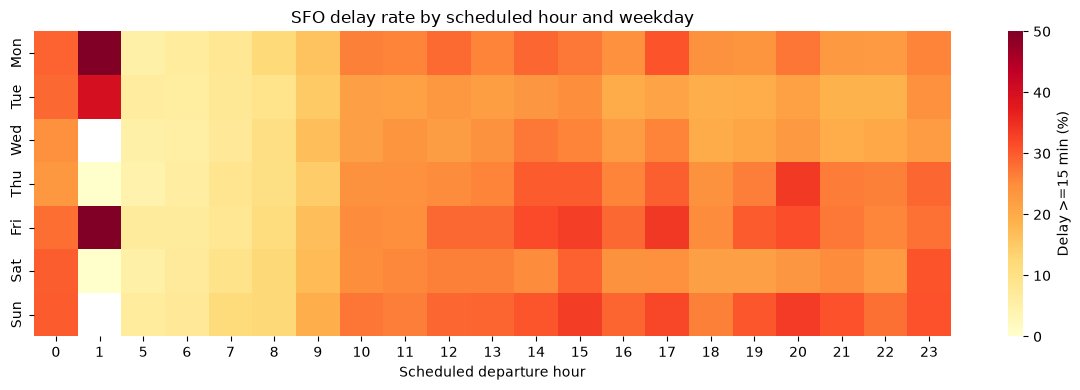

In [6]:
day_names = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
schedule_heatmap = (
    training_df.groupby(["day_of_week", "scheduled_dep_hour"], observed=True)
    ["target_delay_ge_15"]
    .mean()
    .mul(100)
    .unstack()
    .reindex(range(1, 8))
    .rename(index=day_names)
    .astype(float)
)

plt.figure(figsize=(12, 4))
sns.heatmap(schedule_heatmap, cmap="YlOrRd", cbar_kws={"label": "Delay >=15 min (%)"})
plt.xlabel("Scheduled departure hour")
plt.ylabel("")
plt.title("SFO delay rate by scheduled hour and weekday")
plt.tight_layout()
plt.show()


### Which carrier-route pairs are delayed most often?

Only combinations with at least 500 training flights are included so that very small routes do not dominate the comparison.


,flights,delay_ge_15_percent,delay_ge_120_percent
carrier_route,,,
F9 to DFW,846,42.79,7.45
F9 to PHX,1063,38.66,6.21
F9 to ATL,739,38.43,5.28
F9 to LAS,2710,37.08,6.75
WN to LAS,3857,33.83,2.88
WN to LAX,4458,32.71,2.24
WN to SAN,4623,30.59,2.05
WN to DEN,4093,30.52,2.35
WN to PHX,3155,29.03,1.62


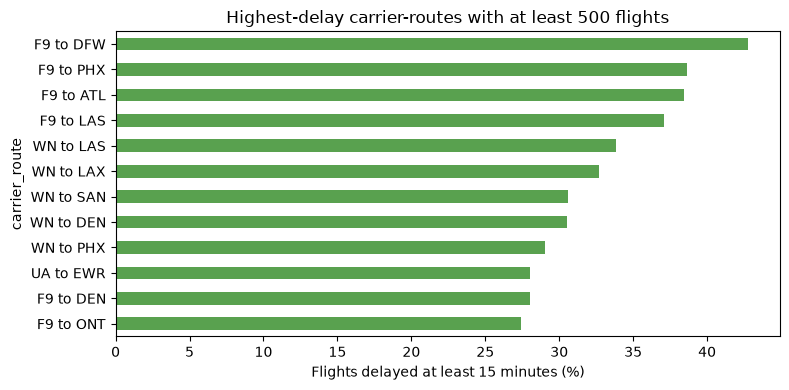

In [7]:
route_data = training_df.assign(
    carrier_route=(
        training_df["reporting_airline"].astype(str)
        + " to "
        + training_df["dest"].astype(str)
    )
)
route_summary = (
    route_data.groupby("carrier_route", observed=True)
    .agg(
        flights=("flight_id", "size"),
        delay_ge_15_percent=("target_delay_ge_15", lambda x: 100 * x.mean()),
        delay_ge_120_percent=("target_delay_bin", lambda x: 100 * x.ge(3).mean()),
    )
    .query("flights >= 500")
    .sort_values("delay_ge_15_percent", ascending=False)
)

display(route_summary.head(15).round(2))
route_summary.head(12)["delay_ge_15_percent"].sort_values().plot.barh(
    figsize=(8, 4),
    color="#59A14F",
    xlabel="Flights delayed at least 15 minutes (%)",
)
plt.title("Highest-delay carrier-routes with at least 500 flights")
plt.tight_layout()
plt.show()


### What causes are reported for delayed flights?

BTS cause minutes describe the current flight after it operates. They are useful for EDA but would leak the outcome if used as model features.


,reported_cause_minutes_percent
Late aircraft,46.18
Carrier,35.45
NAS,16.72
Weather,1.56
Security,0.08


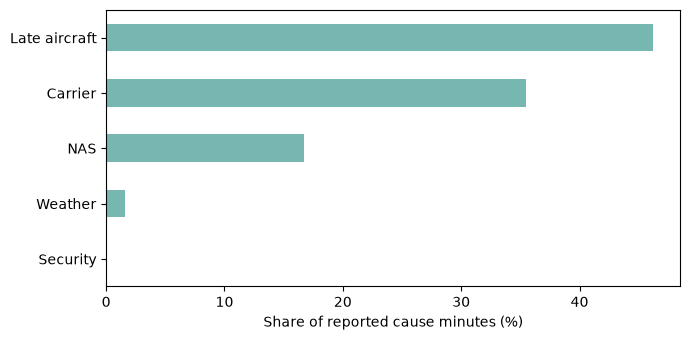

In [8]:
cause_columns = {
    "Carrier": "eda_only_carrier_delay_minutes",
    "Weather": "eda_only_weather_delay_minutes",
    "NAS": "eda_only_nas_delay_minutes",
    "Security": "eda_only_security_delay_minutes",
    "Late aircraft": "eda_only_late_aircraft_delay_minutes",
}
cause_minutes = training_df[list(cause_columns.values())].sum().rename(
    {value: label for label, value in cause_columns.items()}
)
cause_share = (100 * cause_minutes / cause_minutes.sum()).sort_values(ascending=False)

display(cause_share.rename("reported_cause_minutes_percent").round(2).to_frame())
cause_share.sort_values().plot.barh(
    figsize=(7, 3.5), color="#76B7B2", xlabel="Share of reported cause minutes (%)"
)
plt.tight_layout()
plt.show()


### Does extreme SFO weather correspond to more delays?

This comparison groups low visibility, low ceilings, or gusty conditions together and compares them with normal observations.


In [9]:
extreme_weather = (
    training_df["origin_is_low_visibility"].eq(1)
    | training_df["origin_is_low_ceiling"].eq(1)
    | training_df["origin_is_gusty"].eq(1)
)
normal_weather = ~extreme_weather

weather_summary = pd.DataFrame(
    {
        "flights": [normal_weather.sum(), extreme_weather.sum()],
        "delay_ge_15_percent": [
            100 * training_df.loc[normal_weather, "target_delay_ge_15"].mean(),
            100 * training_df.loc[extreme_weather, "target_delay_ge_15"].mean(),
        ],
        "delay_ge_120_percent": [
            100 * training_df.loc[normal_weather, "target_delay_bin"].ge(3).mean(),
            100 * training_df.loc[extreme_weather, "target_delay_bin"].ge(3).mean(),
        ],
    },
    index=["normal SFO conditions", "extreme SFO conditions"],
)

display(weather_summary.round(2))

,flights,delay_ge_15_percent,delay_ge_120_percent
normal SFO conditions,226734,19.86,2.36
extreme SFO conditions,67036,25.52,3.41


### Do FAA aircraft characteristics differ across delay bins?

Aircraft age, seat count, and engine thrust are summarized for EDA. Earlier model comparisons did not show a stable improvement from these fields, so they are excluded later.


In [10]:
faa_by_bin = (
    training_df.groupby("target_delay_bin_label", observed=True)
    .agg(
        flights=("flight_id", "size"),
        median_aircraft_age=("aircraft_age_years", "median"),
        median_seats=("number_of_seats", "median"),
        median_engine_thrust=("engine_thrust", "median"),
    )
    .reindex(LABELS)
)

display(faa_by_bin.round(2))


,flights,median_aircraft_age,median_seats,median_engine_thrust
target_delay_bin_label,,,,
under_15,231634,11.0,182.0,27300.0
15_to_under_60,41573,12.0,182.0,27300.0
60_to_under_120,12927,12.0,182.0,27120.0
120_to_under_240,5752,12.0,190.0,27120.0
240_plus,1884,11.0,199.0,27300.0


### Remove columns that would leak the outcome

Identifiers, current-flight outcomes, and BTS cause fields are not valid model inputs at the configured prediction horizon.


In [11]:
NON_FEATURES = {
    "flight_id",
    "flight_date",
    "scheduled_dep_utc",
    "prediction_cutoff_utc",
    "prediction_horizon_hours",
    "dep_delay_minutes",
    "cancelled",
    "target_cancelled",
    "target_delay_ge_15",
    "target_delay_bin",
    "target_delay_bin_label",
    "eda_only_carrier_delay_minutes",
    "eda_only_weather_delay_minutes",
    "eda_only_nas_delay_minutes",
    "eda_only_security_delay_minutes",
    "eda_only_late_aircraft_delay_minutes",
}

excluded_columns = sorted(NON_FEATURES.intersection(training_df.columns))

candidate_features = [
    column
    for column in training_df.columns
    if column not in NON_FEATURES
]

display(pd.DataFrame({"excluded_column": excluded_columns}))

print(f"Excluded columns: {len(excluded_columns):,}")
print(f"Candidate features after exclusions: {len(candidate_features):,}")

,excluded_column
0,cancelled
1,dep_delay_minutes
2,eda_only_carrier_delay_minutes
3,eda_only_late_aircraft_delay_minutes
4,eda_only_nas_delay_minutes
5,eda_only_security_delay_minutes
6,eda_only_weather_delay_minutes
7,flight_date
8,flight_id
9,prediction_cutoff_utc


Excluded columns: 16
Candidate features after exclusions: 167


### Tail-number assumption

The project assumes the assigned tail number is known at the prediction cutoff. Actual information about its previous flight is still used only when that event occurred before the cutoff.


In [12]:
LINEAGE_FEATURES = {
    "tail_sequence_today", "has_previous_tail_flight", "previous_flight_matches_origin",
    "previous_arrived_by_cutoff", "previous_departed_by_cutoff",
    "previous_arrival_delay_known", "previous_departure_delay_known",
    "scheduled_turnaround_minutes", "minutes_until_previous_scheduled_arrival",
    "minutes_since_previous_actual_arrival",
}
FAA_FEATURES = {
    "aircraft_year_manufactured", "aircraft_type_code", "engine_type_code",
    "aircraft_manufacturer", "aircraft_model", "number_of_engines",
    "number_of_seats", "aircraft_weight_class", "aircraft_cruise_speed",
    "engine_thrust", "faa_record_type", "aircraft_age_years", "faa_match_flag",
}

### How much prior-tail information is available at each configured horizon?

Later cutoffs observe more previous departures and arrivals than earlier cutoffs.


In [13]:
tail_coverage_rows = []
for horizon in CONFIG["horizons"]:
    horizon_data = pd.read_parquet(
        ROOT / f"data/modeling/sfo_delay_features_{horizon}h.parquet",
        columns=[
            "target_delay_bin", "previous_arrived_by_cutoff",
            "previous_departed_by_cutoff"
        ],
    )
    horizon_data = horizon_data.loc[horizon_data["target_delay_bin"].notna()]
    tail_coverage_rows.append(
        {
            "horizon": f"T-{horizon}",
            "previous_arrived_by_cutoff_percent": 100 * horizon_data["previous_arrived_by_cutoff"].mean(),
            "previous_departed_by_cutoff_percent": 100 * horizon_data["previous_departed_by_cutoff"].mean(),
        }
    )

display(pd.DataFrame(tail_coverage_rows).set_index("horizon").round(2))


,previous_arrived_by_cutoff_percent,previous_departed_by_cutoff_percent
horizon,,
T-2,37.63,92.94
T-4,28.83,66.98


### Missingness before feature selection

Missingness is calculated from 2022-2024 so that validation and test coverage do not affect the decision.


,missing_percent
origin_wind_gust_excess_mps,90.33
origin_wind_gust_mps,90.33
origin_wind_gust_max_prior_3h,78.81
previous_arrival_delay_known,62.21
minutes_since_previous_actual_arrival,62.21
...,...
carrier_sfo_departures_observed_6h,0.00
carrier_sfo_departures_observed_24h,0.00
carrier_sfo_arrivals_observed_3h,0.00
carrier_sfo_arrivals_observed_24h,0.00


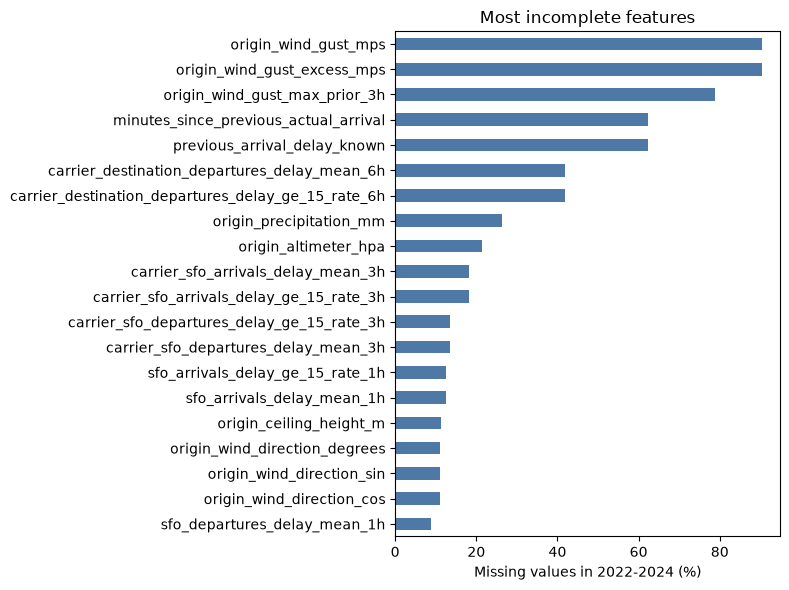

In [14]:
missing_before = (100 * training_df[candidate_features].isna().mean()).sort_values(ascending=False)
display(missing_before.rename("missing_percent").round(2).to_frame())

missing_before.head(20).sort_values().plot.barh(
    figsize=(8, 6), color="#4E79A7", xlabel="Missing values in 2022-2024 (%)"
)
plt.title("Most incomplete features")
plt.tight_layout()
plt.show()


### Feature-selection rules

1. Exclude identifiers, targets, cancellations, and current-flight cause fields.
2. Remove features with at least 90% missing training values.
3. Exclude FAA aircraft specifications because they did not add stable model value.


In [15]:
MISSING_THRESHOLD = 90.0
high_missing_features = missing_before.loc[
    missing_before >= MISSING_THRESHOLD
].index.tolist()

final_features = [
    feature for feature in candidate_features
    if feature not in FAA_FEATURES
    and feature not in high_missing_features
]

dropped_features = pd.DataFrame(
    {
        "missing_percent": missing_before.reindex(
            [*high_missing_features, *sorted(FAA_FEATURES)]
        )
    }
).sort_index()
display(dropped_features.round(2))

,missing_percent
aircraft_age_years,3.27
aircraft_cruise_speed,1.01
aircraft_manufacturer,1.01
aircraft_model,1.01
aircraft_type_code,1.01
aircraft_weight_class,1.01
aircraft_year_manufactured,3.27
engine_thrust,3.06
engine_type_code,1.01
faa_match_flag,0.00


### Correlation check

Spearman correlation is used for a small group of representative numeric variables. The current delay appears only in this EDA figure and is not a model feature.


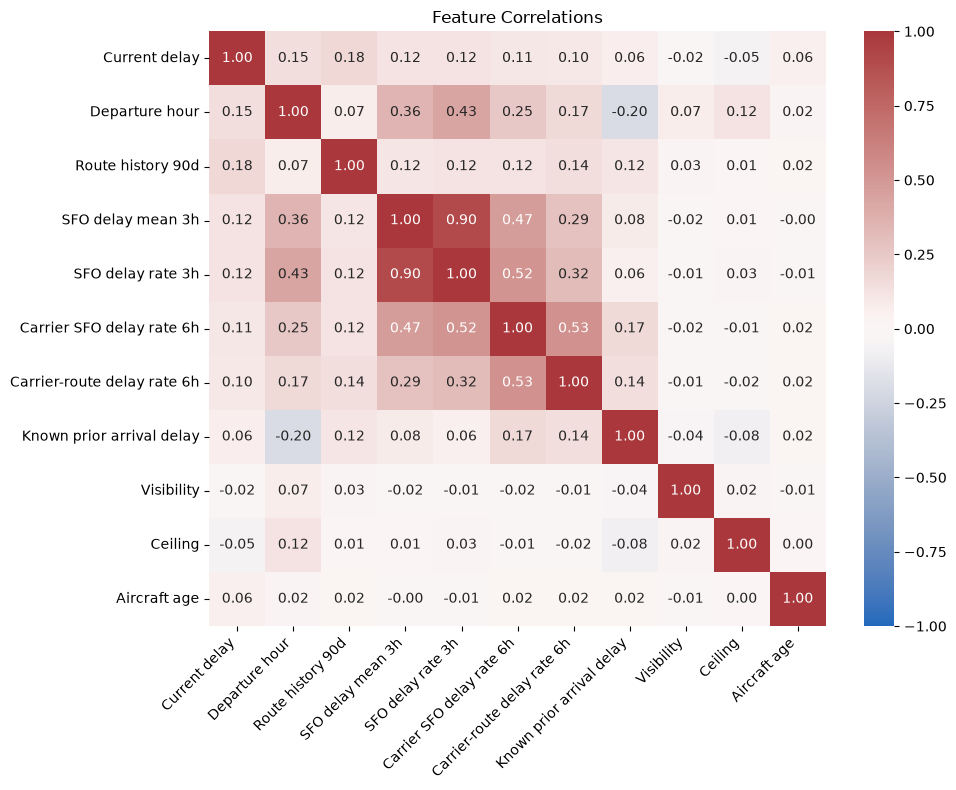

In [16]:
correlation_features = {
    "dep_delay_minutes": "Current delay",
    "scheduled_dep_hour": "Departure hour",
    "hist_carrier_destination_90d_delay_ge_15_rate": "Route history 90d",
    "sfo_departures_delay_mean_3h": "SFO delay mean 3h",
    "sfo_departures_delay_ge_15_rate_3h": "SFO delay rate 3h",
    "carrier_sfo_departures_delay_ge_15_rate_6h": "Carrier SFO delay rate 6h",
    "carrier_destination_departures_delay_ge_15_rate_6h": "Carrier-route delay rate 6h",
    "previous_arrival_delay_known": "Known prior arrival delay",
    "origin_visibility_km": "Visibility",
    "origin_ceiling_height_m": "Ceiling",
    "aircraft_age_years": "Aircraft age",
}

sampled_features = training_df[list(correlation_features)].sample(
    n=min(len(training_df), 60_000),
    random_state=CONFIG["seed"],
)
correlation = sampled_features.corr(method="spearman").rename(
    index=correlation_features,
    columns=correlation_features,
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlation,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    ax=ax,
)

ax.set_title("Feature Correlations")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Features retained for modeling


In [17]:
final_feature_set = pd.DataFrame({"feature": final_features})

display(final_feature_set)

,feature
0,reporting_airline
1,dest
2,day_of_week
3,scheduled_dep_hour
4,scheduled_arr_hour
...,...
147,origin_freezing_precipitation_proxy
148,origin_is_low_visibility
149,origin_is_low_ceiling
150,origin_is_gusty
